# Import Libraries


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Import DataSet

In [13]:
data = pd.read_csv("student.csv")
data.head()

,study_hours,attendance,group_discussion,previous_test_score,final_exam_pass
0,4,72,Yes,89,Fail
1,16,72,Yes,93,Pass
2,4,79,No,61,Fail
3,4,65,Yes,61,Fail
4,20,76,Yes,50,Pass


## 1. Understanding the Basics

### What is Probability?

Probability is the chance that an event will happen. It is measured from 0 to 1 or 0% to 100%.

### Real-life example:
If it is very cloudy, there is a high probability of rain.

### Key Probability Terminology

**Experiment:** An activity that produces an outcome.
Example: Selecting a student from the dataset.

**Outcome:** The result of an experiment.
Example: The selected student passes the exam.

**Event:** A specific outcome or group of outcomes.
Example: A student has attendance above 80%.

**Sample Space:** All possible outcomes.
Example: All 200 students in the dataset.

### Three Probability Event Examples from the Dataset
**Event A:** A student passes the final exam.

**Event B:** A student has attendance above 80%.

**Event C:** A student participates in group discussions.

## 2. Types of Events

**Empirical Probability**

Empirical probability is based on actual data or observations.

**Example:**
In the dataset of 200 students, suppose 140 students passed.

P(Pass)=200 / 140 = 0.70

**Answer:** Probability of passing = 0.70 (70%)

**Real-life example:**
If 70 out of 100 students pass an exam, the empirical probability of passing is 70%.

##  Theoretical Probability

Theoretical probability is based on what should happen according to rules or assumptions.

### Example:
If a student can either Pass or Fail, and both outcomes are equally likely:

P(Pass)= 1 / 2 = 0.50

**Answer:** Probability of passing = 0.50 (50%)

### Real-life example:
When tossing a coin, the probability of getting Heads is:

P(Heads)= 1/2 = 0.50 (50%)

## 3. Random Variable & Probability Distribution

Define the Random Variable

**Let X** = Number of students passing the final exam out of 3 randomly selected students.

### Possible values of X:

X = 0 → No student passes

X = 1 → One student passes

X = 2 → Two students pass

X = 3 → Three students pass

Assume the probability of a student passing is 0.7 (70%) from the dataset.

## Probability Distribution Table

| X (Number of Passes)   | P(X)  |
| --------------------   | ----- |
| 0                      | 0.027 |
| 1                      | 0.189 |
| 2                      | 0.441 |
| 3                      | 0.343 |


In [14]:
# Number of trials
n = 3

# Probability of passing
p = 0.7

# Mean
mean = n * p

# Variance
variance = n * p * (1 - p)

print("Mean =", mean)
print("Variance =", variance)

Mean = 2.0999999999999996
Variance = 0.63


## 4. Venn Diagram in Probability

In [15]:

# Conditions
study_more_than_10 = len(data[data['study_hours'] > 10])

attendance_more_than_80 = len(data[data['attendance'] > 80])

both_conditions = len(
    data[(data['study_hours'] > 10) & (data['attendance'] > 80)]
)

print("Study > 10 Hours:", study_more_than_10)
print("Attendance > 80%:", attendance_more_than_80)
print("Both Conditions:", both_conditions)

Study > 10 Hours: 109
Attendance > 80%: 74
Both Conditions: 37


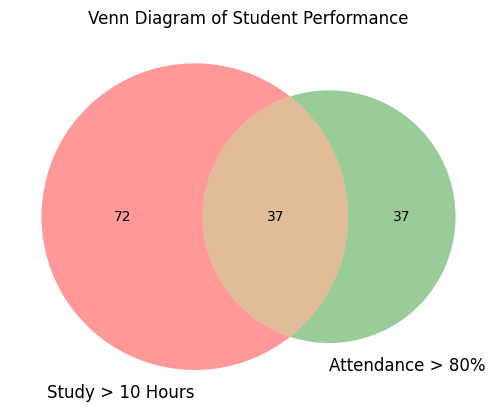

In [16]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

venn2(
    subsets=(
        study_more_than_10 - both_conditions,
        attendance_more_than_80 - both_conditions,
        both_conditions
    ),
    set_labels=('Study > 10 Hours', 'Attendance > 80%')
)

plt.title("Venn Diagram of Student Performance")
plt.show()

# 5. Contingency Table & Probability Calculations

### 1. Create a contingency table

In [17]:


contingency_table = pd.crosstab(
    data['group_discussion'],
    data['final_exam_pass']
)

print(contingency_table)

final_exam_pass   Fail  Pass
group_discussion            
No                  58    48
Yes                 32    62


### 2. Join Probability

In [18]:
joint_prob = len(
    data[(data['group_discussion'] == 'Yes') &
       (data['final_exam_pass'] == 'Pass')]) / len(data)

print("Joint Probability =", joint_prob)

Joint Probability = 0.31


### 3. Marginal Probability

In [19]:
marginal_prob = len(
    data[data['final_exam_pass'] == 'Pass']) / len(data)

print("Marginal Probability =", marginal_prob)

Marginal Probability = 0.55


## 4. Conditional Probability
#### Passes Exam Given Participation in Group Discussion

In [20]:
conditional_prob = len(
    data[(data['group_discussion'] == 'Yes') &
       (data['final_exam_pass'] == 'Pass')]) / len(
    data[data['group_discussion'] == 'Yes'])

print("Conditional Probability =", conditional_prob)

Conditional Probability = 0.6595744680851063


# 6. Understanding Relationships

In [21]:
# Print the probabilities
print("Marginal Pass Probability:", marginal_prob)
print("Conditional Pass Probability (Given Group Discussion):", conditional_prob)
print("Joint Probability (Group Discussion AND Pass):", joint_prob)

# 1. Interpretation of Conditional Probability
print("\nInterpretation:")
print("Conditional probability tells us the chance of passing the exam")
print("when we already know that a student participates in group discussions.")

# 2. Mathematical Test for Independence
print("\n1. Test for Independence:")

print(f"P(Pass | Group Discussion Yes) = {conditional_prob:.4f}")
print(f"P(Pass) = {marginal_prob:.4f}")

if abs(conditional_prob - marginal_prob) < 1e-4:
    print("Result: The probabilities are EQUAL.")
    print("Conclusion: Group Discussion and Passing Exam are Independent Events.")
else:
    print("Result: The probabilities are NOT EQUAL.")
    print("Conclusion: Group Discussion and Passing Exam are Dependent Events.")

# 3. Mathematical Test for Mutual Exclusivity
print("\n2. Test for Mutual Exclusivity:")

print(f"P(Group Discussion Yes AND Pass) = {joint_prob:.4f}")

if joint_prob == 0:
    print("Result: The intersection is 0. The events are Mutually Exclusive.")
     
else:
    print("Result: The intersection is NOT 0. The events are NOT Mutually Exclusive.")
    



Marginal Pass Probability: 0.55
Conditional Pass Probability (Given Group Discussion): 0.6595744680851063
Joint Probability (Group Discussion AND Pass): 0.31

Interpretation:
Conditional probability tells us the chance of passing the exam
when we already know that a student participates in group discussions.

1. Test for Independence:
P(Pass | Group Discussion Yes) = 0.6596
P(Pass) = 0.5500
Result: The probabilities are NOT EQUAL.
Conclusion: Group Discussion and Passing Exam are Dependent Events.

2. Test for Mutual Exclusivity:
P(Group Discussion Yes AND Pass) = 0.3100
Result: The intersection is NOT 0. The events are NOT Mutually Exclusive.


# 7. Byes Theorem Application

In [22]:
 # Given probabilities

P_H_given_P = 0.70      
P_H = 0.60              
P_P = 0.70              

# Bayes Theorem
P_P_given_H = (P_H_given_P * P_P) / P_H

print("--------- Bayes Theorem Calculation ---------")

print(f"P(High Attendance | Pass) = {P_H_given_P}")
print(f"P(Pass) = {P_P}")
print(f"P(High Attendance) = {P_H}")

print("\nProbability of Passing given High Attendance:")
print(f"P(Pass | High Attendance) = {P_P_given_H:.4f}")

print(f"\nPercentage = {P_P_given_H * 100:.2f}%")

print("\nInterpretation:")
print("A student with high attendance (>80%) has about")
print(f"{P_P_given_H * 100:.2f}% chance of passing the exam.")

--------- Bayes Theorem Calculation ---------
P(High Attendance | Pass) = 0.7
P(Pass) = 0.7
P(High Attendance) = 0.6

Probability of Passing given High Attendance:
P(Pass | High Attendance) = 0.8167

Percentage = 81.67%

Interpretation:
A student with high attendance (>80%) has about
81.67% chance of passing the exam.


# Final Summary :

- Higher study hours increase the chances of passing the exam.

- Students with **attendance above 80%** are more likely to **pass.**

- Group discussion participation has a positive impact on exam performance.

- The events **"group discussion participation"** and "passing the exam" are dependent events.

- Students who actively participate in discussions generally have a higher probability of success.

- Using Bayes Theorem, the probability of passing given high attendance was calculated as **81.67%.**
 
- Overall, attendance, study hours, and group discussion participation are the most important factors affecting the probability of passing.